<div style="background-color: #84bfef; padding: 20px; border-radius: 10px">

# Desafio #1 | Equipo: 31 | Simulador Empresarial 
</div>


## 1. Objetivo del EDA y preguntas de negocio

El EDA no busca todavía cerrar conclusiones de negocio, sino verificar si el dataset permite responder las preguntas del desafío, detectar problemas de calidad y preparar las variables necesarias para construir los KPI y el dashboard de ambas áreas de RRHH.

**Áreas del desafío:**

- **Perfil y Desempeño Profesional:** entender el perfil sociodemográfico y laboral de los empleados para orientar políticas de talento, compromiso y desarrollo.
- **Absentismo y Bienestar Laboral:** medir la magnitud del absentismo, revisar su variación temporal y anticipar necesidades de planificación operativa.


### 1.1 Mapa de preguntas de negocio, KPI y columnas

Esta tabla conecta el dataset con las preguntas del desafío. Es una guía inicial para decidir qué columnas parecen necesarias; la selección final se confirmará después de la limpieza.


**Magnitud del absentismo**

KPI / análisis: porcentaje de IDs con registros de ausencia y horas totales.  
Columnas necesarias: `ID`, `Absenteeism_hours`.

**Variación mensual del absentismo**

KPI / análisis: mes pico por horas y por registros.  
Columnas necesarias: `Month_absence`, `Absenteeism_hours`, `ID`.

**Motivo principal de ausencia**

KPI / análisis: motivo modal y motivos con más horas.  
Columnas necesarias: `Reason_absence`, `Absenteeism_hours`, `ID`.

**Continuidad operativa**

KPI / análisis: carga laboral, hit target y horas de ausencia.  
Columnas necesarias: `Work_load_Average_day`, `Absenteeism_hours`, `Hit_target`.

**Perfil sociodemográfico/laboral**

KPI / análisis: distribución por edad, educación, antigüedad y distancia.  
Columnas necesarias: `Age`, `Education`, `Service_time`, `Distance_Residence_Work`, `Son`, `Pet`.

**Desempeño y contexto laboral**

KPI / análisis: relación exploratoria entre perfil, hit target y absentismo.  
Columnas necesarias: `Hit_target`, `Service_time`, `Transportation_expense`, `Body_mass_index`.


## 2. Librerías


In [55]:
import os
from getpass import getpass
from urllib.parse import quote_plus

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv
from sqlalchemy import create_engine, inspect, text

## 3. Conexión y carga de datos | Gestión de credenciales

La conexión se realiza con SQLAlchemy y PyMySQL. Las credenciales reales se cargan desde un archivo `.env` o, si falta algún dato, se solicitan al ejecutar la celda.

El archivo `.env` contiene las credenciales reales de conexión y no debe subirse a GitHub. <br> 
El archivo `.env.example` sirve como plantilla para saber qué variables necesita el proyecto.<br> 
Si `.env` no existe o falta alguna variable, el notebook pedirá los datos por pantalla al ejecutar la celda de conexión.

Para cargar variables desde `.env`, puede ser necesario instalar:

```bash
pip install python-dotenv pymysql sqlalchemy
```

Variables esperadas en `.env`: `MYSQL_HOST`, `MYSQL_PORT`, `MYSQL_USER`, `MYSQL_PASSWORD`, `MYSQL_DATABASE`.


In [56]:
# Cargar variables desde .env si existe.
env_path = find_dotenv(usecwd=True)
load_dotenv(env_path)

# Pedir solo los datos que falten.
mysql_host = os.getenv("MYSQL_HOST") or input("Host MySQL: ")
mysql_port = os.getenv("MYSQL_PORT") or input("Puerto MySQL [3306]: ") or "3306"
mysql_user = os.getenv("MYSQL_USER") or input("Usuario MySQL: ")
mysql_password = os.getenv("MYSQL_PASSWORD") or getpass("Contraseña MySQL: ")
mysql_database = os.getenv("MYSQL_DATABASE") or input("Base de datos MySQL: ")

# quote_plus evita errores si usuario o contraseña contienen caracteres especiales.
connection_url = (
    f"mysql+pymysql://{quote_plus(mysql_user)}:{quote_plus(mysql_password)}"
    f"@{mysql_host}:{mysql_port}/{mysql_database}"
)

engine = create_engine(connection_url)

# Prueba mínima de conexión.
with engine.connect() as conn:
    mysql_version = conn.execute(text("SELECT VERSION() AS version")).scalar()

print(f"Conexión OK | MySQL {mysql_version} | Base de datos: {mysql_database}")

Conexión OK | MySQL 8.0.46 | Base de datos: Equip_31


In [57]:
inspector = inspect(engine)
tablas = inspector.get_table_names()

pd.DataFrame({"tablas_disponibles": tablas})

,tablas_disponibles
0,RRHH


In [58]:
# En este desafío se espera la tabla RRHH.
tabla_rrhh = "RRHH"

if tabla_rrhh not in tablas:
    raise ValueError(f"No se encontró la tabla {tabla_rrhh}. Tablas disponibles: {tablas}")

RRHH = pd.read_sql_table(tabla_rrhh, engine)

# Normalizar nombres para trabajar en Python sin espacios ni caracteres problemáticos.
columnas_originales = RRHH.columns.tolist()
RRHH.columns = (
    RRHH.columns
    .str.strip()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace(r"_+", "_", regex=True)
)

renombrar_columnas = {
    "Reason_for_absence": "Reason_absence",
    "Month_of_absence": "Month_absence",
    "Day_of_the_week": "Day_week",
    "Work_load_Average_day": "Work_load_Average_day",
    "Disciplinary_failure": "Disciplinary_failure",
    "Distance_from_Residence_to_Work": "Distance_Residence_Work",
    "Transportation_expense": "Transportation_expense",
    "Service_time": "Service_time",
    "Hit_target": "Hit_target",
    "Social_drinker": "Social_drinker",
    "Social_smoker": "Social_smoker",
    "Body_mass_index": "Body_mass_index",
    "Absenteeism_time_in_hours": "Absenteeism_hours",
}

RRHH = RRHH.rename(columns=renombrar_columnas)

print("Tabla cargada:", tabla_rrhh)
print("Dimensiones:", RRHH.shape)
RRHH.head()

Tabla cargada: RRHH
Dimensiones: (740, 21)


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112


### 3.1 Validación elemental de lectura

Estas comprobaciones sustituyen la necesidad de repetir todo el EDA en Workbench. Solo validan que Python está leyendo la misma tabla: filas, columnas, muestra inicial y horas totales.


In [59]:
# Detectar el nombre real de la columna de horas en MySQL.
columnas_sql = [col["name"] for col in inspector.get_columns(tabla_rrhh)]
posibles_columnas_horas = ["Absenteeism_hours", "Absenteeism time in hours", "Absenteeism_time_in_hours"]
columna_horas_sql = next((col for col in posibles_columnas_horas if col in columnas_sql), None)

if columna_horas_sql is None:
    raise ValueError(f"No se encontró la columna de horas de absentismo. Columnas disponibles: {columnas_sql}")

validacion_sql = pd.read_sql_query(
    f"""
    SELECT
        COUNT(*) AS filas_sql,
        COUNT(DISTINCT ID) AS ids_unicos_sql,
        SUM(`{columna_horas_sql}`) AS horas_absentismo_sql
    FROM `{tabla_rrhh}`
    """,
    engine
)

validacion_python = pd.DataFrame({
    "filas_python": [len(RRHH)],
    "ids_unicos_python": [RRHH["ID"].nunique()],
    "horas_absentismo_python": [RRHH["Absenteeism_hours"].sum()]
})

validacion_lectura = pd.concat([validacion_sql, validacion_python], axis=1)
validacion_lectura["filas_ok"] = validacion_lectura["filas_sql"] == validacion_lectura["filas_python"]
validacion_lectura["ids_ok"] = validacion_lectura["ids_unicos_sql"] == validacion_lectura["ids_unicos_python"]
validacion_lectura["horas_ok"] = validacion_lectura["horas_absentismo_sql"] == validacion_lectura["horas_absentismo_python"]

validacion_lectura

,filas_sql,ids_unicos_sql,horas_absentismo_sql,filas_python,ids_unicos_python,horas_absentismo_python,filas_ok,ids_ok,horas_ok
0,740,36,5124.0,740,36,5124,True,True,True


## 4. Estructura general del dataset

Se revisan filas, columnas, tipos de datos y una muestra inicial. Esta exploración permite comprobar cómo llega la información antes de realizar cualquier limpieza.


In [60]:
RRHH.shape

(740, 21)

In [61]:
RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       740 non-null    int64
 1   Reason_absence           740 non-null    int64
 2   Month_absence            740 non-null    int64
 3   Day_week                 740 non-null    int64
 4   Seasons                  740 non-null    int64
 5   Transportation_expense   740 non-null    int64
 6   Distance_Residence_Work  740 non-null    int64
 7   Service_time             740 non-null    int64
 8   Age                      740 non-null    int64
 9   Work_load_Average_day    740 non-null    str  
 10  Hit_target               740 non-null    int64
 11  Disciplinary_failure     740 non-null    str  
 12  Education                740 non-null    str  
 13  Son                      740 non-null    str  
 14  Social_drinker           740 non-null    str  
 15  Social_smoker    

In [62]:
RRHH.dtypes

ID                         int64
Reason_absence             int64
Month_absence              int64
Day_week                   int64
Seasons                    int64
Transportation_expense     int64
Distance_Residence_Work    int64
Service_time               int64
Age                        int64
Work_load_Average_day        str
Hit_target                 int64
Disciplinary_failure         str
Education                    str
Son                          str
Social_drinker               str
Social_smoker                str
Pet                          str
Weight                     int64
Height                     int64
Body_mass_index            int64
Absenteeism_hours          int64
dtype: object

**Observación EDA:** `Work_load_Average_day` aparece como texto aunque representa una variable numérica. En este notebook solo se señala el problema; la conversión definitiva debe hacerse en limpieza.


In [63]:
RRHH.head(10)


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
5,11,19,3,2,3,289,36,13,33,"222,196",...,0,1,2,1,0,1,90,172,30,104
6,36,13,6,4,3,118,13,18,50,"377,550",...,0,1,1,1,0,0,98,178,31,80
7,14,18,12,3,2,155,12,14,34,"280,549",...,0,1,2,1,0,0,95,196,25,80
8,13,13,7,2,1,369,17,12,31,"264,604",...,0,1,3,1,0,0,70,169,25,80
9,34,19,12,3,4,118,10,10,37,"261,306",...,0,1,0,0,0,0,83,172,28,64


In [64]:
RRHH.describe(include="all")

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740,...,740,740,740,740,740,740,740.000000,740.000000,740.000000,740.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,...,2,4,5,2,2,6,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"222,196",...,0,1,0,1,0,0,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,...,700,611,298,420,686,460,NaN,NaN,NaN,NaN
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,89.000000,172.000000,31.000000,8.000000


## 5. Unidad de análisis

Antes de analizar, hay que aclarar qué representa cada fila. El dataset tiene 740 registros, pero solo 36 IDs únicos. Esto sugiere que una fila no representa una persona única, sino un episodio o registro asociado a un empleado.


In [65]:
unidad_analisis = pd.DataFrame({
    "metrica": [
        "registros_totales",
        "empleados_unicos_ID",
        "registros_por_empleado_media",
        "registros_por_empleado_max"
    ],
    "valor": [
        len(RRHH),
        RRHH["ID"].nunique(),
        round(RRHH.groupby("ID").size().mean(), 2),
        RRHH.groupby("ID").size().max()
    ]
})

unidad_analisis

,metrica,valor
0,registros_totales,740.00
1,empleados_unicos_ID,36.00
2,registros_por_empleado_media,20.56
3,registros_por_empleado_max,113.00


**Lectura EDA:** los análisis por registro y por empleado no responden exactamente a la misma pregunta. Para absentismo conviene crear una vista por empleado, mientras que para distribución temporal puede tener sentido trabajar por registro.


## 6. Calidad inicial de datos

Se revisan valores nulos, IDs repetidos, duplicados exactos y valores especiales. No se corrige nada todavía; solo se identifican incidencias para la fase de limpieza.


In [66]:
columnas_rrhh = RRHH.columns.tolist()

duplicados_exactos_por_fila = (
    RRHH
    .groupby(columnas_rrhh, dropna=False)
    .size()
    .reset_index(name="times_repeated")
    .query("times_repeated > 1")
)

ids_con_duplicados_exactos = (
    duplicados_exactos_por_fila["ID"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

control_registros = pd.DataFrame({
    "metrica": [
        "TOTAL REGISTROS",
        "ID ÚNICOS",
        "ID extras",
        "ID CON DUPLICADOS EXACTOS"
    ],
    "resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        len(RRHH) - RRHH["ID"].nunique(),
        ids_con_duplicados_exactos.nunique()
    ]
})

control_registros


,metrica,resultado
0,TOTAL REGISTROS,740
1,ID ÚNICOS,36
2,ID extras,704
3,ID CON DUPLICADOS EXACTOS,9


### 6.1 IDs con duplicados exactos

La métrica solicitada aquí es contar **cuántos ID distintos** tienen al menos un registro duplicado exacto. Por eso primero se agrupa por todas las columnas para encontrar filas idénticas y después se cuenta el número de `ID` únicos afectados.


In [67]:
total_ids_con_duplicados_exactos = ids_con_duplicados_exactos.nunique()

total_ids_con_duplicados_exactos


9

In [68]:
ids_con_duplicados_exactos


0     3
1     5
2    10
3    15
4    22
5    24
6    27
7    28
8    34
Name: ID, dtype: int64

In [69]:
detalle_ids_con_duplicados_exactos = (
    duplicados_exactos_por_fila
    .groupby("ID", as_index=False)
    .agg(
        grupos_duplicados_exactos=("times_repeated", "count"),
        filas_implicadas=("times_repeated", "sum"),
        filas_extra=("times_repeated", lambda valores: (valores - 1).sum())
    )
    .sort_values("ID")
    .reset_index(drop=True)
)

detalle_ids_con_duplicados_exactos


,ID,grupos_duplicados_exactos,filas_implicadas,filas_extra
0,3,10,26,16
1,5,1,2,1
2,10,1,2,1
3,15,1,2,1
4,22,3,8,5
5,24,2,4,2
6,27,1,2,1
7,28,2,4,2
8,34,5,10,5


In [70]:
nulos = pd.DataFrame({
    "nulos": RRHH.isna().sum(),
    "% nulos": (RRHH.isna().mean() * 100).round(2)
})

nulos

,nulos,% nulos
ID,0,0.0
Reason_absence,0,0.0
Month_absence,0,0.0
Day_week,0,0.0
Seasons,0,0.0
Transportation_expense,0,0.0
Distance_Residence_Work,0,0.0
Service_time,0,0.0
Age,0,0.0
Work_load_Average_day,0,0.0


### 6.2 Diferencia entre `sum()` y `count()` en `duplicated()`

`duplicated()` devuelve valores booleanos: `True` cuando la fila es duplicada y `False` cuando no lo es. Por eso `sum()` cuenta únicamente los `True`, mientras que `count()` cuenta todas las filas evaluadas. Para contar duplicados se usa `sum()` o `value_counts()`, no `count()`.


In [71]:
duplicados_keep_first = RRHH.duplicated(keep="first")
duplicados_keep_false = RRHH.duplicated(keep=False)

comparacion_duplicados = pd.DataFrame({
    "metrica": [
        "duplicated(keep='first').sum()",
        "duplicated(keep='first').count()",
        "duplicated(keep=False).sum()",
        "duplicated(keep=False).count()"
    ],
    "resultado": [
        duplicados_keep_first.sum(),
        duplicados_keep_first.count(),
        duplicados_keep_false.sum(),
        duplicados_keep_false.count()
    ],
    "interpretacion": [
        "Filas duplicadas exactas extra; las que sobran si eliminamos duplicados.",
        "Total de filas evaluadas; no es una métrica de duplicados.",
        "Todas las filas implicadas en duplicados, incluyendo la primera aparición.",
        "Total de filas evaluadas; no es una métrica de duplicados."
    ]
})

comparacion_duplicados


,metrica,resultado,interpretacion
0,duplicated(keep='first').sum(),34,Filas duplicadas exactas extra; las que sobran...
1,duplicated(keep='first').count(),740,Total de filas evaluadas; no es una métrica de...
2,duplicated(keep=False).sum(),60,"Todas las filas implicadas en duplicados, incl..."
3,duplicated(keep=False).count(),740,Total de filas evaluadas; no es una métrica de...


In [72]:
RRHH.duplicated(keep="first").value_counts()


False    706
True      34
Name: count, dtype: int64

In [73]:
ids_duplicados = (
    RRHH["ID"]
    .value_counts()
    .loc[lambda x: x > 1]
    .reset_index()
)

ids_duplicados.columns = ["ID", "recuento"]

ids_duplicados

,ID,recuento
0,3,113
1,28,76
2,34,55
3,22,46
4,20,42
5,11,40
6,15,37
7,36,34
8,24,30
9,14,29


In [74]:
duplicados_exactos_df = RRHH[RRHH.duplicated(keep=False)].sort_values(list(RRHH.columns))

duplicados_exactos_df

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
453,3,23,7,6,1,179,51,18,38,"239,554",...,0,1,0,1,0,0,89,170,31,2
454,3,23,7,6,1,179,51,18,38,"239,554",...,0,1,0,1,0,0,89,170,31,2
558,3,27,2,2,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2
564,3,27,2,2,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2
379,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
383,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
386,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
388,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
552,3,27,2,4,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2
562,3,27,2,4,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2


### 6.3 Valores especiales a investigar

Algunas variables codificadas pueden contener valores especiales. Por ejemplo, `Month_absence = 0` aparece con pocos registros y debe revisarse antes de interpretar meses o estacionalidad.


In [75]:
valores_especiales = pd.DataFrame({
    "revision": [
        "Month_absence igual a 0",
        "Reason_absence igual a 0",
        "Absenteeism_hours igual a 0"
    ],
    "registros": [
        (RRHH["Month_absence"] == 0).sum(),
        (RRHH["Reason_absence"] == 0).sum(),
        (RRHH["Absenteeism_hours"] == 0).sum()
    ]
})

valores_especiales

,revision,registros
0,Month_absence igual a 0,3
1,Reason_absence igual a 0,43
2,Absenteeism_hours igual a 0,44


**Lectura EDA:** `Reason_absence = 0` y `Absenteeism_hours = 0` no deben interpretarse todavía. Podrían representar ausencia no registrada, registro administrativo, valor especial o dato no informado. Se necesita el diccionario de datos antes de sacar conclusiones.


### 6.4 Diccionario de variables y códigos

Varias columnas son códigos numéricos: `Reason_absence`, `Day_week`, `Seasons` y `Education`. Para negocio no basta con hablar de “motivo 13” o “educación 1”; antes del dashboard se necesita un diccionario que traduzca esos códigos.


In [76]:
codigos_a_documentar = ["Reason_absence", "Day_week", "Seasons", "Education"]

resumen_codigos = []
for col in codigos_a_documentar:
    resumen_codigos.append({
        "variable": col,
        "valores_distintos": RRHH[col].nunique(),
        "valores_observados": sorted(RRHH[col].dropna().unique().tolist())
    })

pd.DataFrame(resumen_codigos)

,variable,valores_distintos,valores_observados
0,Reason_absence,28,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,Day_week,5,"[2, 3, 4, 5, 6]"
2,Seasons,4,"[1, 2, 3, 4]"
3,Education,4,"[1, 2, 3, 4]"


## 7. Variables por área de RRHH

En EDA se puede proponer una primera agrupación de columnas según la pregunta de negocio. Esta propuesta orienta el trabajo, pero no es la selección definitiva de columnas.


In [77]:
columnas_perfil_desempeno = [
    "ID",
    "Age",
    "Education",
    "Service_time",
    "Transportation_expense",
    "Distance_Residence_Work",
    "Hit_target",
    "Work_load_Average_day",
    "Disciplinary_failure",
    "Son",
    "Social_drinker",
    "Social_smoker",
    "Pet",
    "Weight",
    "Height",
    "Body_mass_index"
]

columnas_absentismo_bienestar = [
    "ID",
    "Reason_absence",
    "Month_absence",
    "Day_week",
    "Seasons",
    "Absenteeism_hours",
    "Age",
    "Service_time",
    "Distance_Residence_Work",
    "Transportation_expense",
    "Education",
    "Son",
    "Social_drinker",
    "Social_smoker",
    "Body_mass_index"
]

pd.DataFrame({
    "area": ["Perfil y Desempeño", "Absentismo y Bienestar"],
    "numero_columnas": [len(columnas_perfil_desempeno), len(columnas_absentismo_bienestar)],
    "columnas": [", ".join(columnas_perfil_desempeno), ", ".join(columnas_absentismo_bienestar)]
})

,area,numero_columnas,columnas
0,Perfil y Desempeño,16,"ID, Age, Education, Service_time, Transportati..."
1,Absentismo y Bienestar,15,"ID, Reason_absence, Month_absence, Day_week, S..."


**Nota sobre bienestar:** variables como `Social_drinker`, `Social_smoker`, `Body_mass_index` o `Son` no miden bienestar laboral directamente. En este EDA se tratan solo como variables asociadas o proxys que podrían ayudar a explorar patrones.


## 8. Exploración de Perfil y Desempeño Profesional


In [78]:
perfil_desempeno_resumen = RRHH[columnas_perfil_desempeno].describe(include="all")

perfil_desempeno_resumen

,ID,Age,Education,Service_time,Transportation_expense,Distance_Residence_Work,Hit_target,Work_load_Average_day,Disciplinary_failure,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index
count,740.000000,740.000000,740,740.000000,740.000000,740.000000,740.000000,740,740,740,740,740,740,740.000000,740.000000,740.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,38,2,5,2,2,6,NaN,NaN,NaN
top,NaN,NaN,1,NaN,NaN,NaN,NaN,"222,196",0,0,1,0,0,NaN,NaN,NaN
freq,NaN,NaN,611,NaN,NaN,NaN,NaN,36,700,298,420,686,460,NaN,NaN,NaN
mean,18.017568,36.450000,NaN,12.554054,221.329730,29.631081,94.587838,NaN,NaN,NaN,NaN,NaN,NaN,79.035135,172.114865,26.677027
std,11.021247,6.478772,NaN,4.384873,66.952223,14.836788,3.779313,NaN,NaN,NaN,NaN,NaN,NaN,12.883211,6.034995,4.285452
min,1.000000,27.000000,NaN,1.000000,118.000000,5.000000,81.000000,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,163.000000,19.000000
25%,9.000000,31.000000,NaN,9.000000,179.000000,16.000000,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,69.000000,169.000000,24.000000
50%,18.000000,37.000000,NaN,13.000000,225.000000,26.000000,95.000000,NaN,NaN,NaN,NaN,NaN,NaN,83.000000,170.000000,25.000000
75%,28.000000,40.000000,NaN,16.000000,260.000000,50.000000,97.000000,NaN,NaN,NaN,NaN,NaN,NaN,89.000000,172.000000,31.000000


In [79]:
perfil_por_educacion = (
    RRHH.groupby("Education")
    .agg(
        empleados_unicos=("ID", "nunique"),
        registros=("ID", "count"),
        edad_media=("Age", "mean"),
        servicio_medio=("Service_time", "mean"),
        hit_target_medio=("Hit_target", "mean")
    )
    .round(2)
)

perfil_por_educacion

,empleados_unicos,registros,edad_media,servicio_medio,hit_target_medio
Education,,,,,
1,29,611,37.14,13.06,94.39
2,4,46,34.00,9.46,95.98
3,3,79,32.29,10.33,95.09
4,1,4,41.00,15.00,98.50


In [80]:
perfil_por_empleado = (
    RRHH.groupby("ID")
    .agg(
        registros=("ID", "count"),
        horas_absentismo_totales=("Absenteeism_hours", "sum"),
        horas_absentismo_media=("Absenteeism_hours", "mean"),
        edad=("Age", "first"),
        antiguedad=("Service_time", "first"),
        distancia_trabajo=("Distance_Residence_Work", "first"),
        educacion=("Education", "first"),
        hit_target_medio=("Hit_target", "mean")
    )
    .round(2)
    .reset_index()
)

perfil_por_empleado.head(10)

,ID,registros,horas_absentismo_totales,horas_absentismo_media,edad,antiguedad,distancia_trabajo,educacion,hit_target_medio
0,1,23,121,5.26,37,14,11,3,95.17
1,2,6,25,4.17,48,12,29,1,93.33
2,3,113,482,4.27,38,18,51,1,95.07
3,4,1,0,0.00,40,13,14,1,95.00
4,5,19,104,5.47,43,13,20,1,91.53
5,6,8,72,9.00,33,13,29,1,94.88
6,7,6,30,5.00,39,14,5,1,94.67
7,8,2,0,0.00,39,14,35,1,88.00
8,9,8,262,32.75,58,16,14,1,95.88
9,10,24,186,7.75,28,3,52,1,94.12


## 9. Exploración de Absentismo y Bienestar Laboral

Se calculan agrupaciones descriptivas orientadas a magnitud, motivo y temporalidad. Son aproximaciones iniciales, no conclusiones finales.


In [81]:
absentismo_por_motivo = (
    RRHH.groupby("Reason_absence")
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean")
    )
    .sort_values("horas_totales", ascending=False)
    .round(2)
)

absentismo_por_motivo.head(10)

,registros,empleados_unicos,horas_totales,horas_media
Reason_absence,,,,
13,55,18,842,15.31
19,40,17,729,18.23
23,149,24,424,2.85
28,112,17,335,2.99
11,26,14,297,11.42
22,38,12,293,7.71
10,25,13,276,11.04
26,33,11,240,7.27
18,21,12,217,10.33


In [82]:
absentismo_por_mes = (
    RRHH.groupby("Month_absence")
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean")
    )
    .sort_index()
    .round(2)
)

absentismo_por_mes

,registros,empleados_unicos,horas_totales,horas_media
Month_absence,,,,
0,3,3,0,0.00
1,50,13,222,4.44
2,72,19,294,4.08
3,87,22,765,8.79
4,53,21,482,9.09
5,64,24,400,6.25
6,54,19,411,7.61
7,67,23,734,10.96
8,54,21,288,5.33


In [83]:
absentismo_por_dia = (
    RRHH.groupby("Day_week")
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean")
    )
    .sort_index()
    .round(2)
)

absentismo_por_dia

,registros,empleados_unicos,horas_totales,horas_media
Day_week,,,,
2,161,30,1489,9.25
3,154,28,1229,7.98
4,156,29,1115,7.15
5,125,29,553,4.42
6,144,26,738,5.12


## 10. Primeros KPI exploratorios

Estos KPI se calculan para comprobar que el dataset permite responder a las preguntas de negocio. No se presentan como resultado definitivo porque todavía falta limpieza y validación de códigos.


**Advertencia sobre el denominador:** el porcentaje de empleados con ausencia se calcula sobre los IDs presentes en el dataset. Si la tabla no contiene la plantilla completa de la empresa, no representa el porcentaje real de empleados ausentes sobre toda la organización.


In [84]:
empleados_totales_dataset = RRHH["ID"].nunique()
empleados_con_ausencia = RRHH.loc[RRHH["Absenteeism_hours"] > 0, "ID"].nunique()
porcentaje_empleados_con_ausencia = round((empleados_con_ausencia / empleados_totales_dataset) * 100, 2)

mes_mas_horas = absentismo_por_mes["horas_totales"].idxmax()
motivo_mas_frecuente = RRHH["Reason_absence"].mode().iloc[0]
motivo_mas_horas = absentismo_por_motivo["horas_totales"].idxmax()

kpi_preliminares = pd.DataFrame({
    "kpi_exploratorio": [
        "% IDs del dataset con al menos una ausencia > 0 horas",
        "mes con más horas de absentismo",
        "motivo más frecuente",
        "motivo con más horas totales",
        "horas totales de absentismo"
    ],
    "valor": [
        porcentaje_empleados_con_ausencia,
        mes_mas_horas,
        motivo_mas_frecuente,
        motivo_mas_horas,
        RRHH["Absenteeism_hours"].sum()
    ],
    "nota_eda": [
        "Calculado solo sobre IDs presentes en esta tabla; no representa toda la plantilla si faltan empleados sin registros.",
        "Pendiente revisar Month_absence = 0 y diccionario de meses.",
        "Pendiente traducir códigos de Reason_absence.",
        "Pendiente traducir códigos de Reason_absence.",
        "Cifra preliminar antes de limpiar duplicados exactos."
    ]
})

kpi_preliminares

,kpi_exploratorio,valor,nota_eda
0,% IDs del dataset con al menos una ausencia > ...,91.67,Calculado solo sobre IDs presentes en esta tab...
1,mes con más horas de absentismo,3.00,Pendiente revisar Month_absence = 0 y dicciona...
2,motivo más frecuente,23.00,Pendiente traducir códigos de Reason_absence.
3,motivo con más horas totales,13.00,Pendiente traducir códigos de Reason_absence.
4,horas totales de absentismo,5124.00,Cifra preliminar antes de limpiar duplicados e...


## 11. Visualizaciones mínimas orientadas a negocio

Se incluyen pocas visualizaciones y con propósito: temporalidad, motivos, día de la semana y comparación por grupos. Se usa una paleta sobria y consistente para no introducir ruido visual. Las variables temporales o secuenciales se muestran en su orden lógico.


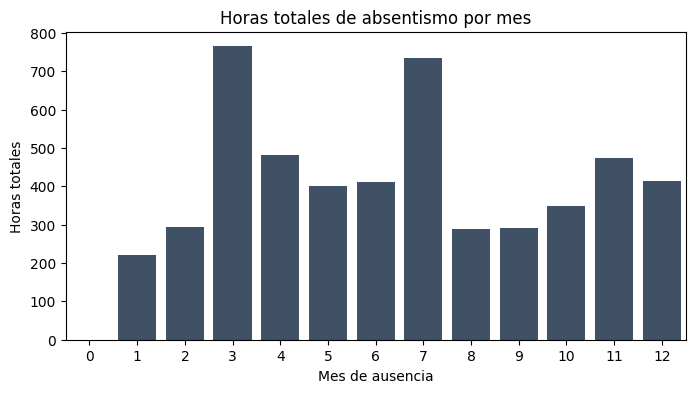

In [85]:
color_principal = "#3A506B"

plt.figure(figsize=(8, 4))
sns.barplot(data=absentismo_por_mes.reset_index(), x="Month_absence", y="horas_totales", color=color_principal)
plt.title("Horas totales de absentismo por mes")
plt.xlabel("Mes de ausencia")
plt.ylabel("Horas totales")
plt.show()

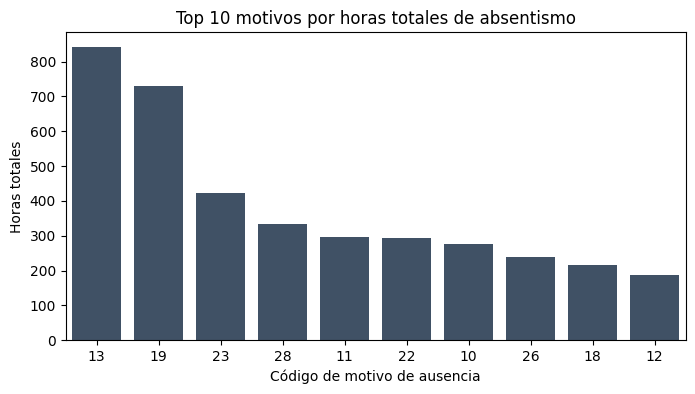

In [86]:
top_motivos = absentismo_por_motivo.head(10).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=top_motivos, x="Reason_absence", y="horas_totales", color=color_principal, order=top_motivos["Reason_absence"])
plt.title("Top 10 motivos por horas totales de absentismo")
plt.xlabel("Código de motivo de ausencia")
plt.ylabel("Horas totales")
plt.show()

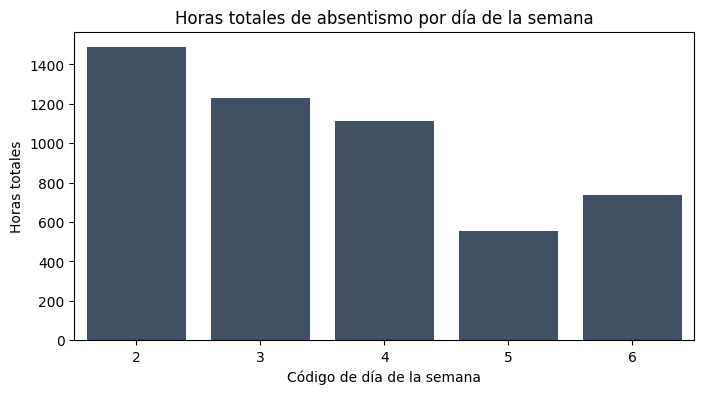

In [87]:
plt.figure(figsize=(8, 4))
sns.barplot(data=absentismo_por_dia.reset_index(), x="Day_week", y="horas_totales", color=color_principal)
plt.title("Horas totales de absentismo por día de la semana")
plt.xlabel("Código de día de la semana")
plt.ylabel("Horas totales")
plt.show()

,grupo_edad,horas_media,registros,empleados_unicos
0,<=30,5.435028,177,7
1,31-40,7.063981,422,18
2,41-50,6.962121,132,10
3,>50,29.111111,9,2


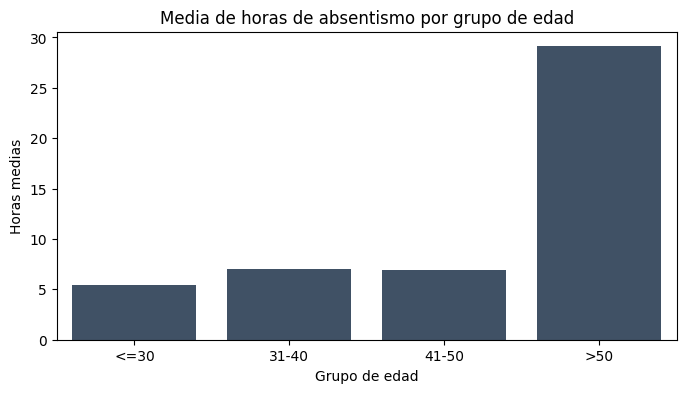

In [88]:
edad_bins = pd.cut(RRHH["Age"], bins=[0, 30, 40, 50, 100], labels=["<=30", "31-40", "41-50", ">50"])
absentismo_por_edad = (
    RRHH.assign(grupo_edad=edad_bins)
    .groupby("grupo_edad", observed=False)
    .agg(
        horas_media=("Absenteeism_hours", "mean"),
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique")
    )
    .reset_index()
)

display(absentismo_por_edad)

plt.figure(figsize=(8, 4))
sns.barplot(data=absentismo_por_edad, x="grupo_edad", y="horas_media", color=color_principal)
plt.title("Media de horas de absentismo por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Horas medias")
plt.show()


**Lectura EDA:** el gráfico por grupo de edad debe interpretarse con cautela. La media puede cambiar mucho si un grupo tiene pocos registros o pocos empleados únicos; por eso se muestra también la tabla de volumen. <br>
Recomendación visual: añadir una etiqueta sobre cada barra con el número de empleados único en cada grupo de edad.


Nota metodológica: `Work_load_Average_day` se mantiene sin transformar en esta fase.<br> 
La conversión a variable numérica se realizará en la fase de limpieza.


Exploración complementaria para Perfil y Desempeño

– Distribución de empleados únicos por nivel educativo.
– Media de Hit_target por nivel educativo o por tramo de antigüedad.
– Distribución de empleados únicos por grupo de edad.


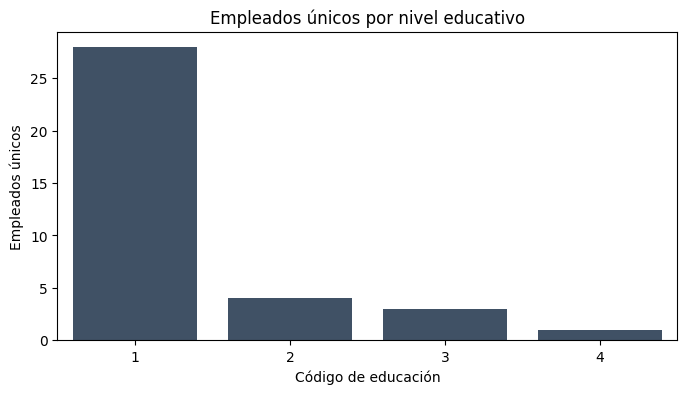

In [89]:
perfil_empleados_unicos = (
    RRHH.groupby("ID")
    .agg(
        edad=("Age", "first"),
        educacion=("Education", "first"),
        antiguedad=("Service_time", "first"),
        hit_target_medio=("Hit_target", "mean")
    )
    .reset_index()
)

empleados_por_educacion = (
    perfil_empleados_unicos["educacion"]
    .value_counts()
    .sort_index()
    .reset_index()
)

empleados_por_educacion.columns = ["educacion", "empleados_unicos"]

plt.figure(figsize=(8, 4))
sns.barplot(
    data=empleados_por_educacion,
    x="educacion",
    y="empleados_unicos",
    color=color_principal
)

plt.title("Empleados únicos por nivel educativo")
plt.xlabel("Código de educación")
plt.ylabel("Empleados únicos")
plt.show()

,educacion,hit_target_medio,empleados_unicos
0,1,94.14,28
1,2,95.60,4
2,3,95.24,3
3,4,97.20,1


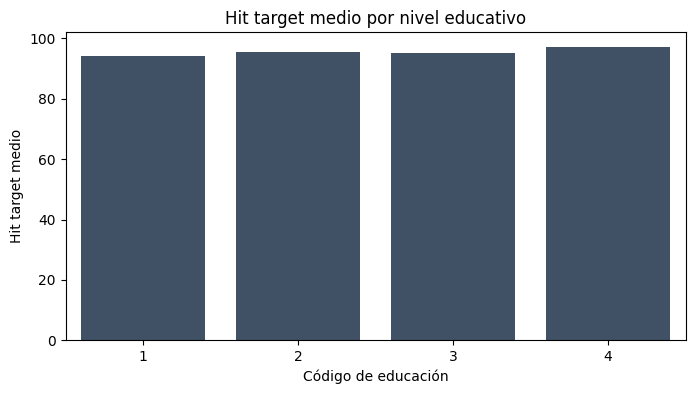

In [90]:
hit_target_por_educacion = (
    perfil_empleados_unicos
    .groupby("educacion")
    .agg(
        hit_target_medio=("hit_target_medio", "mean"),
        empleados_unicos=("ID", "nunique")
    )
    .round(2)
    .reset_index()
)

display(hit_target_por_educacion)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=hit_target_por_educacion,
    x="educacion",
    y="hit_target_medio",
    color=color_principal
)

plt.title("Hit target medio por nivel educativo")
plt.xlabel("Código de educación")
plt.ylabel("Hit target medio")
plt.show()

Lectura EDA: esta exploración permite empezar a describir el perfil laboral de los empleados únicos y revisar si variables como educación, antigüedad o edad pueden aportar segmentación útil para el área de Perfil y Desempeño. Como los códigos de educación todavía no están documentados, no se interpretan categorías concretas en esta fase.


## 12. Incidencias detectadas para limpieza

Esta lista recoge lo que debería resolverse o documentarse antes de crear datasets finales y dashboard.


In [91]:
incidencias_limpieza = pd.DataFrame({
    "incidencia": [
        "Credenciales fuera del notebook",
        "Work_load_Average_day como texto",
        "Duplicados exactos",
        "Month_absence = 0",
        "Códigos sin diccionario",
        "Unidad de análisis mixta"
    ],
    "accion_recomendada": [
        "Usar variables de entorno o .env ignorado por Git",
        "Convertir a numérico en limpieza",
        "Revisar y decidir si eliminar",
        "Investigar si es código especial o dato no informado",
        "Conseguir/documentar equivalencias de Reason_absence, Day_week, Seasons y Education",
        "Separar análisis por registro y análisis por empleado"
    ]
})

incidencias_limpieza


,incidencia,accion_recomendada
0,Credenciales fuera del notebook,Usar variables de entorno o .env ignorado por Git
1,Work_load_Average_day como texto,Convertir a numérico en limpieza
2,Duplicados exactos,Revisar y decidir si eliminar
3,Month_absence = 0,Investigar si es código especial o dato no inf...
4,Códigos sin diccionario,Conseguir/documentar equivalencias de Reason_a...
5,Unidad de análisis mixta,Separar análisis por registro y análisis por e...


## 13. Vistas analíticas propuestas para después de limpieza

Estas vistas se crean como propuesta de trabajo. No sustituyen a los datasets finales, porque antes hay que limpiar tipos, duplicados y valores especiales.


In [92]:
df_perfil_desempeno = RRHH[columnas_perfil_desempeno].copy()
df_absentismo_bienestar = RRHH[columnas_absentismo_bienestar].copy()

print("df_perfil_desempeno:", df_perfil_desempeno.shape)
print("df_absentismo_bienestar:", df_absentismo_bienestar.shape)
print("perfil_por_empleado:", perfil_por_empleado.shape)


df_perfil_desempeno: (740, 16)
df_absentismo_bienestar: (740, 15)
perfil_por_empleado: (36, 9)


## 14. Hallazgos de EDA y siguientes pasos

- El dataset permite empezar a responder las dos áreas del desafío, pero necesita limpieza antes de presentar conclusiones de negocio.
- Una fila parece representar un registro o episodio asociado a un empleado, no una persona única.
- `ID` permite construir una vista por empleado, clave para conectar perfil/desempeño con absentismo.
- Los KPI preliminares se calculan solo sobre los IDs presentes en la tabla; si faltan empleados sin registros, no representan porcentajes sobre toda la plantilla.
- Hay 34 duplicados exactos y valores especiales como `Month_absence = 0`, `Reason_absence = 0` y `Absenteeism_hours = 0` que deben revisarse.
- Falta un diccionario de códigos para traducir variables como `Reason_absence`, `Education`, `Day_week` y `Seasons`.
- Las variables usadas como aproximación a bienestar no miden bienestar laboral directamente.
- La fase siguiente debería limpiar tipos, documentar códigos y construir los datasets finales por área para el dashboard.


## 15. Investigación de repetición por ID

Esta sección ayuda a comprobar si un mismo `ID` aparece muchas veces porque existen registros distintos asociados al empleado, por ejemplo en diferentes meses, días, motivos u horas. La repetición de `ID` no se interpreta automáticamente como duplicado.


In [93]:
resumen_por_id = (
    RRHH
    .groupby("ID")
    .agg(
        total_filas=("ID", "count"),
        meses_distintos=("Month_absence", "nunique"),
        dias_distintos=("Day_week", "nunique"),
        motivos_distintos=("Reason_absence", "nunique"),
        estaciones_distintas=("Seasons", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_distintas=("Absenteeism_hours", "nunique")
    )
    .sort_values("total_filas", ascending=False)
)

resumen_por_id


,total_filas,meses_distintos,dias_distintos,motivos_distintos,estaciones_distintas,horas_totales,horas_distintas
ID,,,,,,,
3,113,12,5,14,4,482,9
28,76,11,5,16,4,347,9
34,55,12,5,14,4,344,10
22,46,11,5,9,4,253,8
20,42,11,5,11,4,306,8
11,40,11,5,11,4,450,10
15,37,12,5,9,4,253,9
36,34,10,5,9,4,311,9
24,30,10,5,11,4,254,9


### 15.1 Variación de columnas dentro de cada ID

Este bloque cuenta cuántos valores distintos tiene cada columna para cada `ID`. Si un empleado tiene muchos valores diferentes en meses, días, motivos u horas, probablemente sus filas representan situaciones distintas y no duplicados.


In [94]:
variacion_por_id = (
    RRHH
    .groupby("ID")
    .nunique()
    .sort_values("ID")
)

variacion_por_id


,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
ID,,,,,,,,,,,,,,,,,,,,
1,13,10,5,4,1,1,1,1,17,11,2,1,1,1,1,1,1,1,1,7
2,4,4,3,2,1,1,1,1,4,2,2,1,1,1,1,1,1,1,1,3
3,14,12,5,4,1,1,1,1,30,13,2,1,1,1,1,1,1,1,1,9
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,5,9,5,4,1,1,1,1,14,9,2,1,1,1,1,1,1,1,1,5
6,5,5,3,4,1,1,1,1,7,5,1,1,1,1,1,1,1,1,1,2
7,4,4,4,4,1,1,1,1,5,3,2,1,1,1,1,1,1,1,1,5
8,1,2,2,2,1,1,1,1,2,2,2,1,1,1,1,1,1,1,1,1
9,5,5,3,4,1,1,1,1,5,4,1,1,1,1,1,1,1,1,1,6


### 15.2 Revisión del ID con más registros

Se muestra el detalle del `ID` con más filas para observar si sus registros cambian por mes, día, motivo u horas de absentismo.


In [95]:
id_mas_repetido = resumen_por_id.index[0]

registros_id_mas_repetido = (
    RRHH[RRHH["ID"] == id_mas_repetido]
    .sort_values(["Month_absence", "Day_week", "Reason_absence", "Absenteeism_hours"])
)

print(f"ID con más registros: {id_mas_repetido}")
registros_id_mas_repetido


ID con más registros: 3


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
416,3,27,1,4,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,3
665,3,28,1,4,2,179,51,18,38,"330,061",...,0,1,0,1,0,0,89,170,31,1
417,3,27,1,5,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,3
551,3,27,1,6,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,2
666,3,28,1,6,2,179,51,18,38,"330,061",...,0,1,0,1,0,0,89,170,31,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,3,28,12,2,2,179,51,18,38,"236,629",...,0,1,0,1,0,0,89,170,31,3
27,3,13,12,3,4,179,51,18,38,"280,549",...,0,1,0,1,0,0,89,170,31,32
660,3,28,12,5,4,179,51,18,38,"236,629",...,0,1,0,1,0,0,89,170,31,1
661,3,28,12,6,4,179,51,18,38,"236,629",...,0,1,0,1,0,0,89,170,31,1


### 15.3 IDs con muchas filas

Esta tabla permite revisar empleados con un volumen alto de registros. Sirve para priorizar inspecciones manuales antes de decidir si existe un problema de duplicidad.


In [96]:
ids_muchas_filas = resumen_por_id[resumen_por_id["total_filas"] > 10]

ids_muchas_filas


,total_filas,meses_distintos,dias_distintos,motivos_distintos,estaciones_distintas,horas_totales,horas_distintas
ID,,,,,,,
3,113,12,5,14,4,482,9
28,76,11,5,16,4,347,9
34,55,12,5,14,4,344,10
22,46,11,5,9,4,253,8
20,42,11,5,11,4,306,8
11,40,11,5,11,4,450,10
15,37,12,5,9,4,253,9
36,34,10,5,9,4,311,9
24,30,10,5,11,4,254,9


**Lectura EDA:** si los IDs con muchas filas tienen varios meses, días, motivos u horas distintas, la repetición del `ID` refleja múltiples registros asociados al mismo empleado. Solo deberían tratarse como duplicados las filas completamente idénticas o aquellas que negocio confirme como registros repetidos.
